# NB-02 — CLIP Encoder & Contrastive Learning

**Goal:** Understand how CLIP aligns images and text in a shared embedding space.

**Key questions:**
1. How does CLIP enable zero-shot classification without task-specific training?
2. What is contrastive learning and InfoNCE loss?
3. How do we use CLIP for retrieval and similarity search?

---

## Concept: Contrastive Learning in Plain English

CLIP trains two encoders (image + text) so that **matching pairs are close** and **non-matching pairs are far apart** in embedding space.

```
Training batch of N (image, caption) pairs:

  Image Encoder → [img_1, img_2, ..., img_N]
  Text Encoder  → [txt_1, txt_2, ..., txt_N]

  Similarity matrix (N×N):
              txt_1  txt_2  txt_3
    img_1  [  HIGH    low    low  ]  ← img_1 should match txt_1
    img_2  [  low    HIGH    low  ]
    img_3  [  low    low    HIGH  ]

  InfoNCE loss: maximize diagonal, minimize off-diagonal
```

At inference, we never fine-tune — we just compare a new image to text labels and pick the highest score (**zero-shot classification**).

In [14]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import BytesIO
from PIL import Image

from src.encoders.clip_encoder import CLIPVisionEncoder, _as_clip_embedding_tensor

DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

COMMONS_API = "https://commons.wikimedia.org/w/api.php"
# Wikimedia requires a descriptive User-Agent (see https://meta.wikimedia.org/wiki/User-Agent_policy)
WIKI_HEADERS = {
    "User-Agent": "VisionMind-NB02/1.0 (https://github.com/maple3788/VisionMind; notebook@local)",
    "Accept": "application/json",
}
# Use Referer when downloading from upload.wikimedia.org (reduces 403s)
IMAGE_HEADERS = {
    **WIKI_HEADERS,
    "Referer": "https://commons.wikimedia.org/",
}


def _commons_file_title(url_or_title: str) -> str | None:
    """Extract ``File:...`` title from a Commons page URL or return if already a title."""
    if url_or_title.startswith("File:"):
        return url_or_title
    marker = "/wiki/File:"
    if marker in url_or_title:
        from urllib.parse import unquote

        name = url_or_title.split(marker, 1)[1].split("#", 1)[0].split("?", 1)[0]
        return f"File:{unquote(name)}"
    return None


def _resolve_commons_image_url(file_title: str, thumb_height: int = 320) -> str:
    """Resolve a Commons file to a direct image URL via the API (same as the wiki UI)."""
    params = {
        "action": "query",
        "format": "json",
        "titles": file_title,
        "prop": "imageinfo",
        "iiprop": "url|size|mime",
        "iiurlheight": thumb_height,
    }
    resp = requests.get(COMMONS_API, params=params, headers=WIKI_HEADERS, timeout=15)
    resp.raise_for_status()
    query = resp.json().get("query", {})
    pages = query.get("pages", {})
    for page in pages.values():
        # pageid -1 means the file does not exist on Commons
        if page.get("missing") or int(page.get("pageid", -1)) < 0:
            continue
        info_list = page.get("imageinfo")
        if not info_list:
            continue
        info = info_list[0]
        return info.get("thumburl") or info.get("url")
    # Hint: API may normalize underscores → spaces; check spelling on Commons
    normalized = query.get("normalized", [{}])
    hint = normalized[0].get("to") if normalized else file_title
    raise ValueError(f"Commons file not found: {file_title} (normalized: {hint})")


def load_image(
    url_or_file: str,
    fallback_color: tuple[int, int, int] = (128, 128, 128),
    thumb_height: int = 320,
) -> Image.Image:
    """Load an image from a direct URL or a Wikimedia Commons ``File:`` page."""
    try:
        file_title = _commons_file_title(url_or_file)
        if file_title is not None:
            image_url = _resolve_commons_image_url(file_title, thumb_height=thumb_height)
        else:
            image_url = url_or_file

        resp = requests.get(image_url, headers=IMAGE_HEADERS, timeout=15)
        resp.raise_for_status()
        return Image.open(BytesIO(resp.content)).convert("RGB")
    except Exception as exc:
        print(f"Warning: failed to load {url_or_file!r} ({exc}) — using fallback color")
        arr = np.full((224, 224, 3), fallback_color, dtype=np.uint8)
        return Image.fromarray(arr)

print("Loading CLIP (ViT-L/14)... first run downloads ~1.7GB")
encoder = CLIPVisionEncoder(device=DEVICE)
print(f"Hidden size: {encoder.hidden_size}, patches: {encoder.num_patches}")

Device: mps
Loading CLIP (ViT-L/14)... first run downloads ~1.7GB


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

Hidden size: 1024, patches: 256


## 1. Zero-Shot Classification

Give CLIP 5 images and 5 text labels — no training. Build a similarity matrix and see if the diagonal wins.

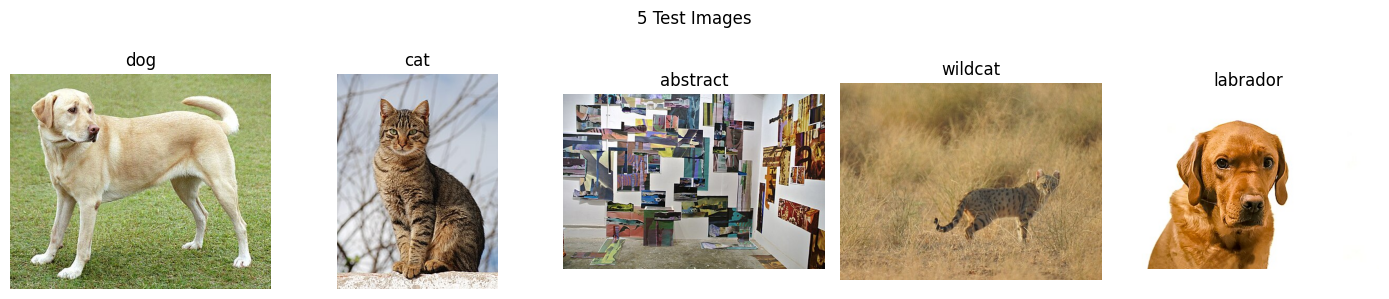

Similarity matrix shape: (5, 5)
[[0.256 0.191 0.102 0.123 0.3  ]
 [0.193 0.276 0.125 0.248 0.189]
 [0.141 0.144 0.172 0.08  0.122]
 [0.14  0.201 0.092 0.227 0.128]
 [0.241 0.173 0.11  0.083 0.241]]


In [9]:
# Use Commons File: page URLs — load_image() resolves them via the API
IMAGE_SOURCES = [
    ("https://commons.wikimedia.org/wiki/File:YellowLabradorLooking_new.jpg", (180, 120, 80)),
    ("https://commons.wikimedia.org/wiki/File:Cat_November_2010-1a.jpg", (200, 180, 160)),
    ("https://commons.wikimedia.org/wiki/File:Abstract_art.jpg", (80, 160, 220)),
    ("https://commons.wikimedia.org/wiki/File:Asiatic_wild_cat_also_called_Desert_cat.jpg", (160, 140, 100)),
    ("https://commons.wikimedia.org/wiki/File:Harmony_-_Labrador_Retriever.jpg", (210, 190, 120)),
]

LABELS = ["a photo of a dog", "a photo of a cat", "a colorful abstract image", "a wild cat in nature", "a labrador retriever"]
CATEGORIES = ["dog", "cat", "abstract", "wildcat", "labrador"]

images = [load_image(src, color) for src, color in IMAGE_SOURCES]

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, img, cat in zip(axes, images, CATEGORIES):
    ax.imshow(img)
    ax.set_title(cat)
    ax.axis("off")
plt.suptitle("5 Test Images")
plt.tight_layout()
plt.show()

sim_matrix = encoder.compute_similarity(images, LABELS).cpu().numpy()
print("Similarity matrix shape:", sim_matrix.shape)
print(sim_matrix.round(3))

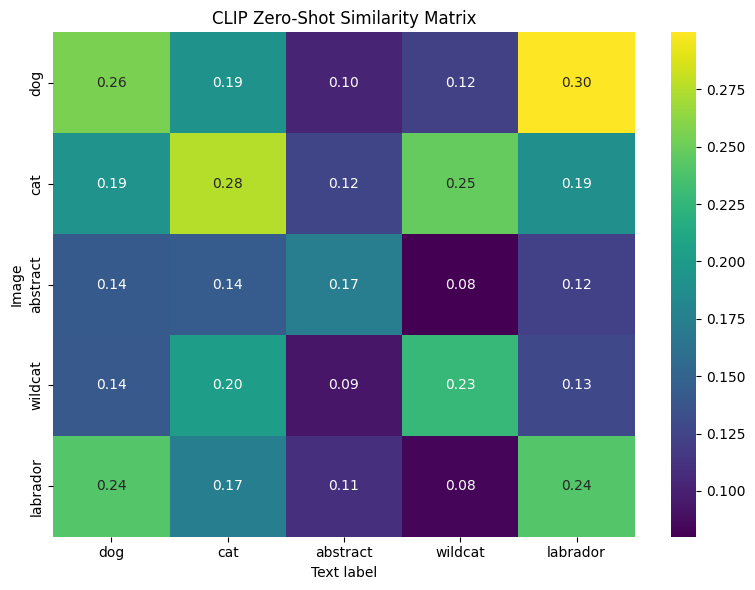

Image 'dog' → predicted 'labrador' (score=0.300)
Image 'cat' → predicted 'cat' (score=0.276)
Image 'abstract' → predicted 'abstract' (score=0.172)
Image 'wildcat' → predicted 'wildcat' (score=0.227)
Image 'labrador' → predicted 'dog' (score=0.241)


In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    sim_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=[c[:10] for c in CATEGORIES],
    yticklabels=CATEGORIES,
    cmap="viridis",
)
plt.title("CLIP Zero-Shot Similarity Matrix")
plt.xlabel("Text label")
plt.ylabel("Image")
plt.tight_layout()
plt.show()

predictions = sim_matrix.argmax(axis=1)
for i, pred_idx in enumerate(predictions):
    print(f"Image '{CATEGORIES[i]}' → predicted '{CATEGORIES[pred_idx]}' (score={sim_matrix[i, pred_idx]:.3f})")

## 2. Image vs Description — Same Concept?

Compare an image embedding against a literal description vs an unrelated caption.

In [11]:
dog_image = images[0]
queries = [
    "a photo of a dog",
    "a fluffy canine sitting outdoors",
    "a photo of an airplane",
    "a bowl of soup",
]

scores = encoder.compute_similarity([dog_image], queries)[0].cpu().numpy()
for q, s in zip(queries, scores):
    bar = "█" * int(max(0, s) * 30)
    print(f"{s:+.3f}  {bar:<30}  {q}")

+0.256  ███████                         a photo of a dog
+0.191  █████                           a fluffy canine sitting outdoors
+0.148  ████                            a photo of an airplane
+0.155  ████                            a bowl of soup


## 3. UMAP Embedding Space Visualization

Embed 20 images (4 per category), project to 2D with UMAP, and color by category.

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

/Users/mapleandrew/AIproject/VisionMind/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


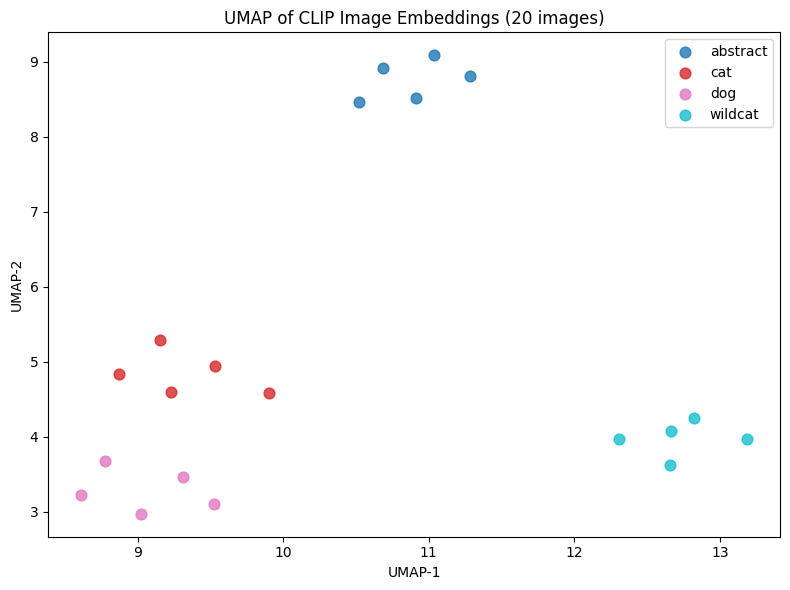

In [15]:
try:
    import umap
except ImportError:
    raise ImportError("Install umap-learn: pip install umap-learn")

from transformers import CLIPModel, CLIPProcessor

# Build a larger image set by repeating with slight color shifts
base_images = images[:4]
gallery: list[Image.Image] = []
gallery_labels: list[str] = []

for label, img in zip(CATEGORIES[:4], base_images):
    for shift in range(5):
        arr = np.array(img).astype(np.int16)
        arr = np.clip(arr + shift * 8, 0, 255).astype(np.uint8)
        gallery.append(Image.fromarray(arr))
        gallery_labels.append(label)

processor = CLIPProcessor.from_pretrained(encoder.model_id)
clip_model = CLIPModel.from_pretrained(encoder.model_id).to(DEVICE).eval()

with torch.no_grad():
    inputs = processor(images=gallery, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(DEVICE)
    raw = clip_model.get_image_features(pixel_values=pixel_values)
    embeddings = _as_clip_embedding_tensor(raw)
    embeddings = embeddings / embeddings.norm(dim=-1, keepdim=True)

reducer = umap.UMAP(n_components=2, random_state=42)
coords = reducer.fit_transform(embeddings.cpu().numpy())

plt.figure(figsize=(8, 6))
unique_labels = sorted(set(gallery_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    mask = [l == label for l in gallery_labels]
    pts = coords[mask]
    plt.scatter(pts[:, 0], pts[:, 1], label=label, alpha=0.8, s=60, c=[color])
plt.legend()
plt.title("UMAP of CLIP Image Embeddings (20 images)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()

## 4. Text-Guided Image Retrieval

Given a text query, find the closest image from a gallery.

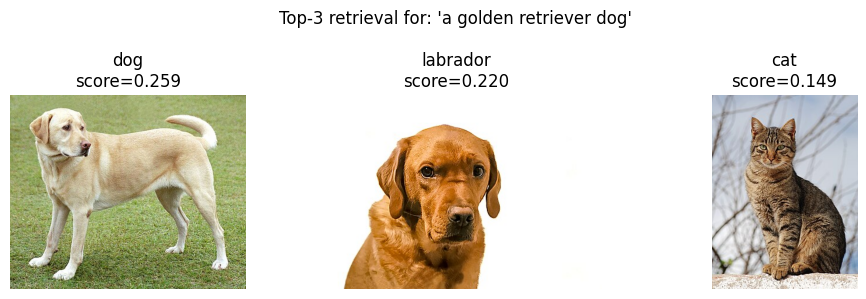

In [16]:
gallery = images
gallery_names = CATEGORIES
query = "a golden retriever dog"

scores = encoder.compute_similarity(gallery, [query]).squeeze(1).cpu().numpy()
ranked = sorted(zip(gallery_names, scores, gallery), key=lambda x: x[1], reverse=True)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for ax, (name, score, img) in zip(axes, ranked[:3]):
    ax.imshow(img)
    ax.set_title(f"{name}\nscore={score:.3f}")
    ax.axis("off")
plt.suptitle(f"Top-3 retrieval for: '{query}'")
plt.tight_layout()
plt.show()

## 5. Sequence Features for the Multimodal Pipeline

For our QA system, we need **token sequences** (not just pooled vectors) to feed the projector.

In [ ]:
seq_feats = encoder.encode_image([images[0]])
print(f"encode_image() shape: {seq_feats.shape}")
print(f"  → [batch, num_patches+1, hidden_size]")
print(f"  → CLIP ViT-L/14: [1, 257, 1024]")
print()
print("We'll pass these patch tokens to the MLP/Q-Former projector in Phase 2.")

## ✅ Phase 1 (Part B) Checklist

- [ ] I understand contrastive learning and InfoNCE
- [ ] I can explain zero-shot classification with CLIP
- [ ] I know CLIP outputs `[batch, seq_len, hidden]` for the vision tower
- [ ] `CLIPVisionEncoder` in `src/encoders/clip_encoder.py` is tested

**Next:** Phase 2 — Input Projectors (`NB-03-linear-projector.ipynb`)